# Harmonic seasonal trend analysis
Here, I make use of the seasonal trend pattern outline in Pasquerella et al. (2017, 2022) and Zhu et al. (2014). This uses a simplified Fourier transform to fit harmonic curves to data for a specific pixel using the formula: $$EVI_{norm} = a_0 + b_0x_t + \sum_{j \in N} \big[ a_j \sin \big(\frac{2\pi j}{T}x_t\big) + b_j \cos \big(\frac{2\pi j}{T} x_t \big)\big] + \varepsilon_t$$
"Where $x_t$ is the ordinal date of each observation; $a_0$ is the modeled intercept; $b_0$ is the modeled slope, $N$ is a set of of integers specifing the frequency, $j$, of the Fourier series harmonics ($N = {1, 3}$, correspondin to 12-month and 4-month harmonics); $a_j$ are the sine coefficients; and $b_j$ are the cosine coefficients; $T$ is the number of days in a year ($T=365.25$); and $\varepsilon_t$ is the residual error term for each observation." (Pasquerella et al., 2017)

## Imports

In [1]:
import geemap
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('use_inf_as_na',True)

import datetime
import pwlf
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

#Sci-kit imports
from sklearn.linear_model import LinearRegression # Ordinary Least Squares Regression
from sklearn.metrics import mean_squared_error, r2_score

## Load data

In [2]:
# Data location
imageset = '../images/images_MtPleasant/'
modelset_1 = '../data/harmonic_1_MtPleasant.pkl'
modelset_2 = '../data/harmonic_2_MtPleasant.pkl'

In [3]:
# get the filenames for all tif files
data_path = Path(imageset) 
file_list = np.array(sorted(list(data_path.glob('*.tif'))))

# an open list to store data array
da_list = []

for filename in file_list:
    # Sentinel-2
    date = filename.name.split('T')[0] # get rid of .tif
    date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    
    # Landsat
    #date = filename.name.split('_')[2] # get rid of .tif
    #date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    with rasterio.open(filename, 'r') as src:
        im = src.read()
        # read image into ndarray

        # transpose the matrix from (band, row, col) to (row, col, band)
        im = np.transpose(im, [1,2,0])

        # set null values
        im[im == 0.] = np.nan

        # get coordinates
        # first axis, from north to south
        lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
        # second axis, from west to east
        lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

        src.close()
        
        da = xr.Dataset({'EVI':(('lat','lon'),im[:,:,0]), 'NIRv':(('lat','lon'),im[:,:,1])},
                        coords={'lat':lat_array,'lon':lon_array})
        
        # add time dimension
        da = da.expand_dims('time')
        da.coords['time'] = [np.datetime64(date)]
        
        # append the data array to da_list
        
        da_list.append(da)
        
images = xr.merge(da_list)

## Analysis

### Add Day of Year and ordinal date

In [4]:
def add_doy_year(df):
    safe_df = df.copy()
    
    safe_df['Year'] = safe_df['time'].map(lambda x: x.year)
    safe_df = safe_df[safe_df['Year'] > 2018]
    safe_df['doy'] = safe_df['time'].map(lambda x: x.timetuple().tm_yday)
    safe_df['ord_date'] = safe_df['doy'] + 365.25 * ((safe_df['Year'] - safe_df['Year'].min()))
    return safe_df

def normalize_VI(df, band):
    safe_df = df.copy()
    transformed = safe_df[['Year', band]]
    
    safe_df[f'{band}_nrml'] = transformed.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))[band]
    return safe_df

### Create harmonic features

In [5]:
def create_harmonics(x, frequencies):
    df = pd.DataFrame({'x': x})
    for j in frequencies:
        sin_j = np.sin(2 * np.pi * j / 365.25 * x)
        cos_j = np.cos(2 * np.pi * j / 365.25 * x)
        
        df[f'sin_{j}'] = sin_j
        df[f'cos_{j}'] = cos_j
        
    return df

### Fit Linear Regression - Single Point Test

In [6]:
freq = [1, 3]

In [40]:
df = images.isel(lat=18, lon=67).to_pandas().reset_index().dropna()
df = add_doy_year(df)
df = normalize_VI(df, 'EVI')
X_train = create_harmonics(df['ord_date'], freq)
y_train = df['EVI_nrml']

In [50]:
df['lon'].iloc[1]

386315.775862069

In [42]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_train)

In [43]:
print('Coefficients: \n', lin_reg.coef_)
print('Root mean squared error: %.2f' % np.sqrt(mean_squared_error(y_train, y_pred)))
print('Coefficient of determination: %.2f' % r2_score(y_train, y_pred))

Coefficients: 
 [ 8.46539151e-05 -2.64158533e-01 -3.99781410e-01  5.49088893e-02
 -7.91809573e-02]
Root mean squared error: 0.21
Coefficient of determination: 0.64


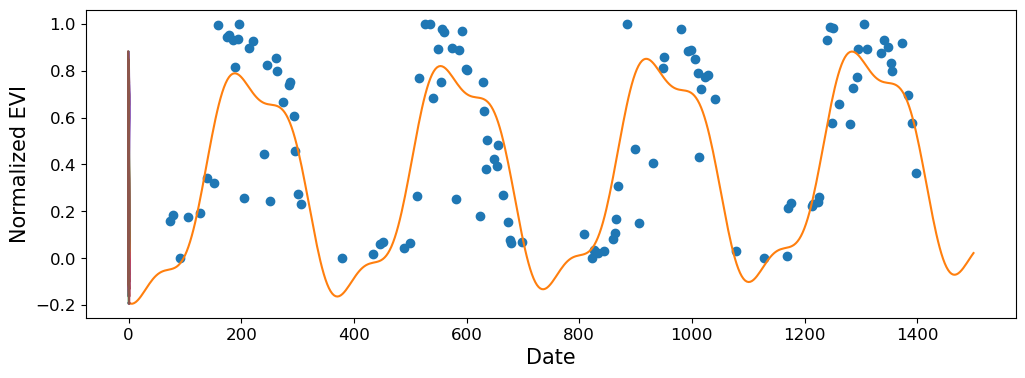

In [44]:
X_grid = create_harmonics(np.linspace(1, 1500, 500), freq)
y_grid = lin_reg.predict(X_grid)

plt.figure(figsize=(12,4))

plt.plot(X_train['x'], y_train, 'o')

plt.ylabel('Normalized EVI', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.plot(X_grid, y_grid)

In [45]:
df['EVI_nrml_pred'] = y_pred
#mask = df['EVI_nrml'] >= 0.9 * df['EVI_nrml_pred']
mask = df['EVI_nrml'] - df['EVI_nrml_pred'] >= -0.2
X_train_2 = create_harmonics(df.loc[mask, 'ord_date'], freq)
y_train_2 = df.loc[mask, 'EVI_nrml']

In [46]:
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_train_2, y_train_2)

y_pred_2 = lin_reg_2.predict(X_train_2)

In [47]:
print('Coefficients: \n', lin_reg_2.coef_)
print('Root mean squared error: %.2f' % np.sqrt(mean_squared_error(y_train_2, y_pred_2)))
print('Coefficient of determination: %.2f' % r2_score(y_train_2, y_pred_2))

Coefficients: 
 [ 4.33597256e-05 -2.75446369e-01 -4.49104419e-01  6.80629200e-02
 -7.07268705e-02]
Root mean squared error: 0.13
Coefficient of determination: 0.85


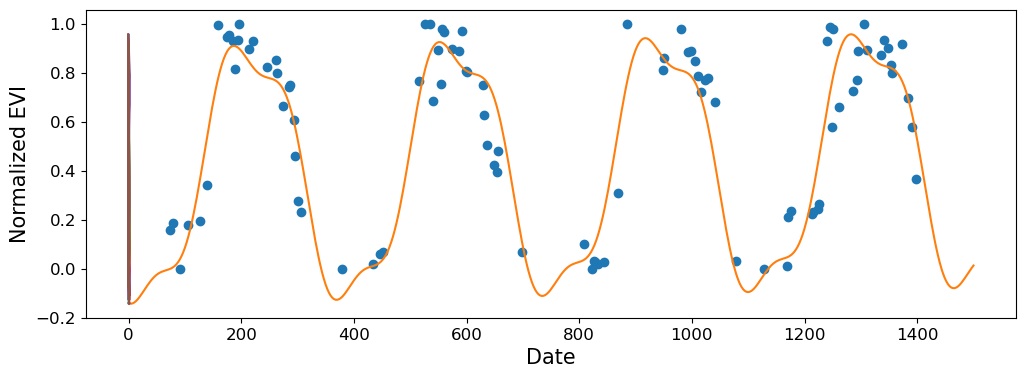

In [48]:
X_grid_2 = create_harmonics(np.linspace(1, 1500, 500), freq)
y_grid_2 = lin_reg_2.predict(X_grid)

plt.figure(figsize=(12,4))

plt.plot(X_train_2['x'], y_train_2, 'o')

plt.ylabel('Normalized EVI', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.plot(X_grid_2, y_grid_2)

### Fit Linear Regression to entire region

In [17]:
def fit_model(latitude, longitude, freq):
    df = images.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    df = add_doy_year(df)
    df = normalize_VI(df, 'EVI')
    X_train = create_harmonics(df['ord_date'], freq)
    y_train = df['EVI_nrml']
    
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    
    return lin_reg

def fit_refit_model(latitude, longitude, freq):
    df = images.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    df = add_doy_year(df)
    df = normalize_VI(df, 'EVI')
    X_train = create_harmonics(df['ord_date'], freq)
    y_train = df['EVI_nrml']
    
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)

    df['EVI_nrml_pred'] = y_pred = lin_reg.predict(X_train)
    mask = df['EVI_nrml'] >= 0.9 * df['EVI_nrml_pred']
    X_train_2 = create_harmonics(df.loc[mask, 'ord_date'], freq)
    y_train_2 = df.loc[mask, 'EVI_nrml']
    
    lin_reg_2 = LinearRegression()
    lin_reg_2.fit(X_train_2, y_train_2)
    
    return lin_reg_2

In [18]:
defol_1_fit = pd.DataFrame(columns = ['lat', 'lon', 'model'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            defol_1_fit.loc[len(defol_1_fit.index)] = [y, x, fit_model(y, x, freq)]
            pbar.update(1)
            
defol_1_fit.to_pickle(modelset_1)

  0%|          | 0/8892 [00:00<?, ?it/s]

In [22]:
defol_2_fit = pd.DataFrame(columns = ['lat', 'lon', 'model'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            defol_2_fit.loc[len(defol_2_fit.index)] = [y, x, fit_refit_model(y, x, freq)]
            pbar.update(1)

defol_2_fit.to_pickle(modelset_2)

  0%|          | 0/8892 [00:00<?, ?it/s]